# Predicting Thyroid Cancer Recurrence

A machine learning project that predicts whether well-differentiated thyroid cancer will recur, using clinicopathologic features from a 15-year patient cohort.

**Author:** Mohannad Janahi
 
**Tools:** Python, pandas, scikit-learn, matplotlib, seaborn

## Problem Statement

Thyroid cancer has a relatively good prognosis, but recurrence still affects a meaningful share of patients. Identifying who is at higher risk early can help clinicians tailor follow-up and treatment.

In this project, I build and compare classification models to predict the binary target **`Recurred`** (`Yes` / `No`) from patient demographics, clinical history, tumor characteristics, and staging information.

### Dataset

- **Source:** [UCI ML Repository — Differentiated Thyroid Cancer Recurrence](https://archive.ics.uci.edu/dataset/915/differentiated+thyroid+cancer+recurrence)
- **Records:** 383 patients followed for at least 10 years
- **Features:** 16 clinicopathologic variables (age, gender, smoking history, TNM staging, pathology, etc.)
- **Target:** Whether the cancer recurred

> **Note on `Response`:** Treatment response is measured after initial therapy. I evaluate two modeling setups:
> 1. **Baseline (no `Response`)** — features available around diagnosis / staging
> 2. **Extended (with `Response`)** — includes post-treatment response, which is more predictive but not available at initial diagnosis

## 1. Setup

In [9]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42

## 2. Load Data

In [10]:
df = pd.read_csv("Thyroid_Diff.csv")
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [11]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Missing values: {df.isna().sum().sum()}")
df.info()

Shape: 383 rows x 17 columns
Missing values: 0
<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Age                   383 non-null    int64
 1   Gender                383 non-null    str  
 2   Smoking               383 non-null    str  
 3   Hx Smoking            383 non-null    str  
 4   Hx Radiothreapy       383 non-null    str  
 5   Thyroid Function      383 non-null    str  
 6   Physical Examination  383 non-null    str  
 7   Adenopathy            383 non-null    str  
 8   Pathology             383 non-null    str  
 9   Focality              383 non-null    str  
 10  Risk                  383 non-null    str  
 11  T                     383 non-null    str  
 12  N                     383 non-null    str  
 13  M                     383 non-null    str  
 14  Stage                 383 non-null    str  
 15  Response             

## 3. Exploratory Data Analysis

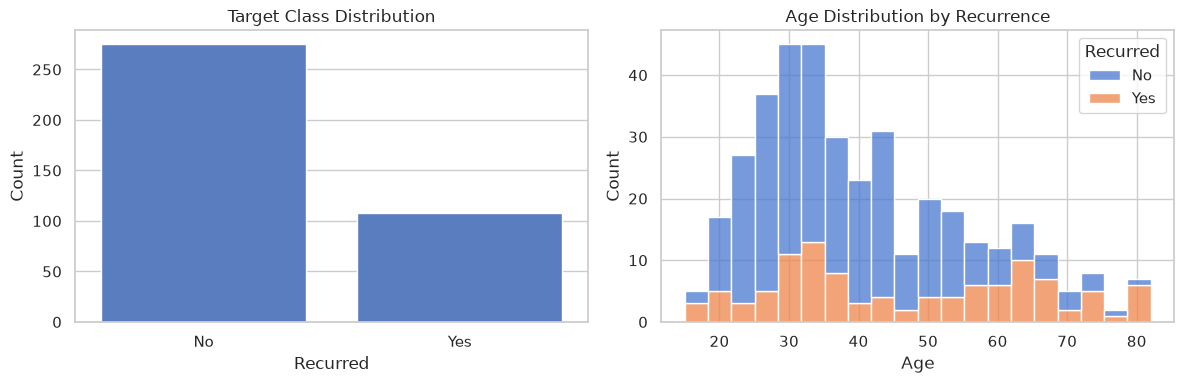

Recurrence rate: 28.2% (108 / 383 patients)


In [12]:
target_counts = df["Recurred"].value_counts()
recurrence_rate = (target_counts["Yes"] / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="Recurred", ax=axes[0])
axes[0].set_title("Target Class Distribution")
axes[0].set_xlabel("Recurred")
axes[0].set_ylabel("Count")

sns.histplot(data=df, x="Age", hue="Recurred", multiple="stack", bins=20, ax=axes[1])
axes[1].set_title("Age Distribution by Recurrence")

plt.tight_layout()
plt.show()

print(f"Recurrence rate: {recurrence_rate}% ({target_counts['Yes']} / {len(df)} patients)")

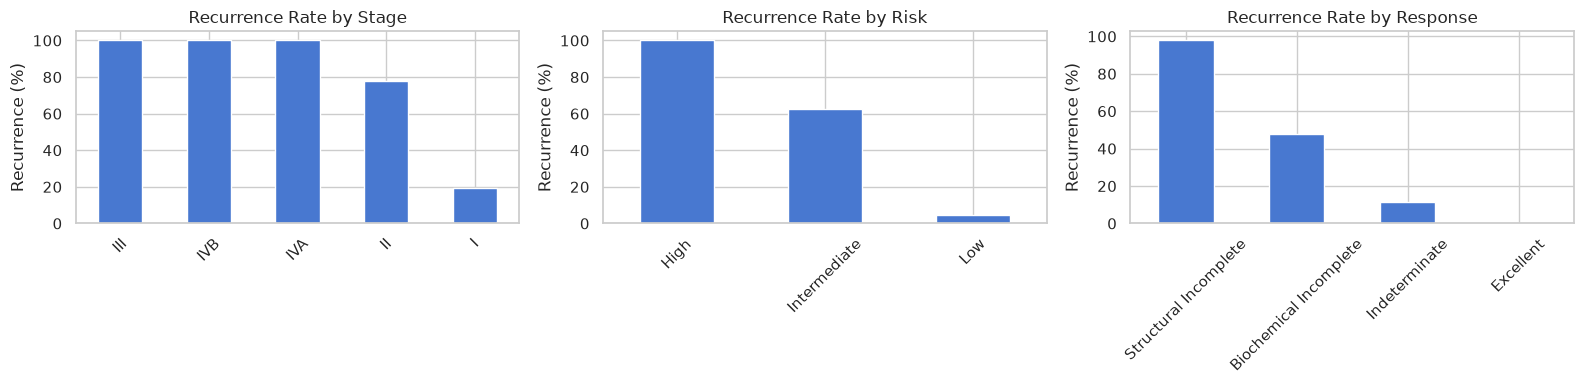

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, column in zip(axes, ["Stage", "Risk", "Response"]):
    rates = df.groupby(column)["Recurred"].apply(lambda s: (s == "Yes").mean() * 100)
    rates.sort_values(ascending=False).plot(kind="bar", ax=ax, color=sns.color_palette()[0])
    ax.set_title(f"Recurrence Rate by {column}")
    ax.set_ylabel("Recurrence (%)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**EDA takeaways**

- The dataset is moderately imbalanced (~28% recurrence).
- Higher-stage disease and incomplete treatment response are associated with higher recurrence rates.
- Age alone does not cleanly separate the classes, so multivariate modeling is needed.

## 4. Preprocessing

Categorical features are one-hot encoded and `Age` is standardized. All preprocessing is wrapped in a scikit-learn `Pipeline` to avoid data leakage between train and test folds.

In [14]:
y = (df["Recurred"] == "Yes").astype(int)

FEATURE_SETS = {
    "baseline": [col for col in df.columns if col not in ["Recurred", "Response"]],
    "extended": [col for col in df.columns if col != "Recurred"],
}

NUMERIC_FEATURES = ["Age"]


def build_preprocessor(feature_columns):
    categorical_features = [col for col in feature_columns if col not in NUMERIC_FEATURES]
    return ColumnTransformer(
        [
            ("num", StandardScaler(), NUMERIC_FEATURES),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )


def build_pipeline(model, feature_columns):
    return Pipeline(
        [
            ("preprocessor", build_preprocessor(feature_columns)),
            ("model", model),
        ]
    )


MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    "SGD Classifier": SGDClassifier(
        loss="hinge",
        penalty="elasticnet",
        max_iter=1000,
        random_state=RANDOM_STATE,
    ),
}

X_baseline = df[FEATURE_SETS["baseline"]]
X_extended = df[FEATURE_SETS["extended"]]

X_baseline.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I


## 5. Model Comparison (5-Fold Cross-Validation)

Accuracy alone can be misleading on imbalanced data, so I report **F1**, **precision**, and **recall** alongside accuracy.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1"]

results = []

for feature_set_name, X in [("baseline", X_baseline), ("extended", X_extended)]:
    feature_columns = FEATURE_SETS[feature_set_name]
    for model_name, model in MODELS.items():
        pipeline = build_pipeline(model, feature_columns)
        scores = cross_validate(pipeline, X, y, cv=cv, scoring=scoring)
        results.append(
            {
                "Feature set": feature_set_name,
                "Model": model_name,
                "Accuracy": scores["test_accuracy"].mean(),
                "Precision": scores["test_precision"].mean(),
                "Recall": scores["test_recall"].mean(),
                "F1": scores["test_f1"].mean(),
            }
        )

results_df = pd.DataFrame(results).sort_values(["Feature set", "F1"], ascending=[True, False])
results_df.style.format({"Accuracy": "{:.1%}", "Precision": "{:.1%}", "Recall": "{:.1%}", "F1": "{:.1%}"})

,Feature set,Model,Accuracy,Precision,Recall,F1
1,baseline,Linear SVM,88.3%,81.1%,76.8%,78.3%
0,baseline,Logistic Regression,88.0%,81.7%,74.9%,77.2%
2,baseline,Random Forest,86.4%,75.1%,79.6%,76.4%
3,baseline,SGD Classifier,83.8%,78.2%,70.6%,69.7%
4,extended,Logistic Regression,96.1%,96.3%,89.8%,92.8%
6,extended,Random Forest,95.8%,93.6%,91.6%,92.4%
5,extended,Linear SVM,95.3%,91.9%,91.6%,91.6%
7,extended,SGD Classifier,93.7%,90.0%,87.8%,88.6%


## 6. Final Evaluation on Hold-Out Test Set

I train the best **baseline** model (Random Forest, no `Response`) on 80% of the data and evaluate on a held-out 20% split.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_baseline,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

final_model = build_pipeline(
    RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced"
    ),
    FEATURE_SETS["baseline"],
)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

              precision    recall  f1-score   support

          No       0.96      0.85      0.90        55
         Yes       0.71      0.91      0.80        22

    accuracy                           0.87        77
   macro avg       0.84      0.88      0.85        77
weighted avg       0.89      0.87      0.87        77



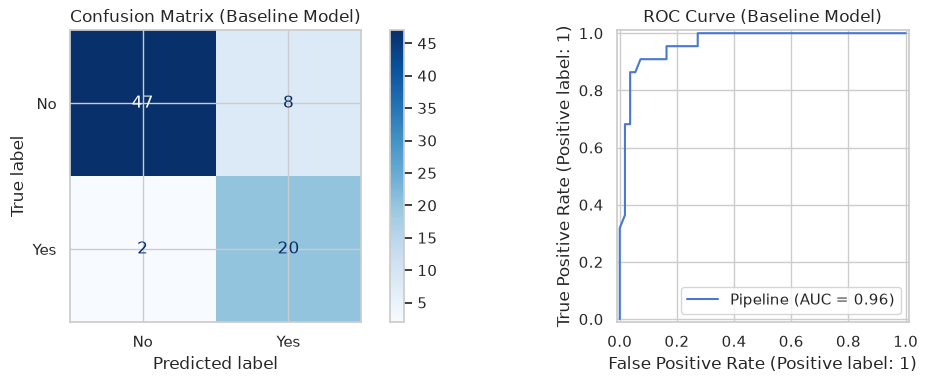

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No", "Yes"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix (Baseline Model)")

RocCurveDisplay.from_estimator(final_model, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC Curve (Baseline Model)")

plt.tight_layout()
plt.show()

## 7. Feature Importance

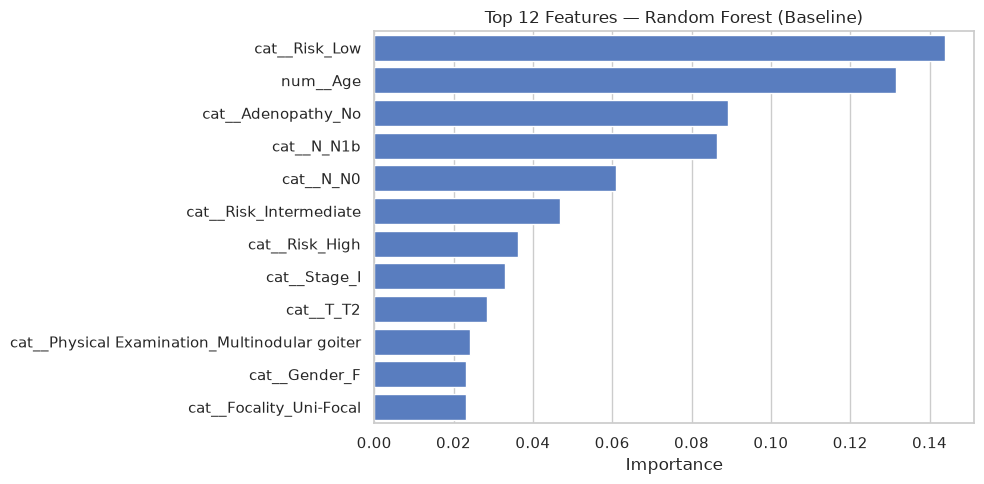

In [18]:
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
importances = final_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(12)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x="importance", y="feature", orient="h")
plt.title("Top 12 Features — Random Forest (Baseline)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 8. Conclusions

### Key findings

- Models that include **`Response`** reach very high performance (~93% F1), confirming that post-treatment response is strongly associated with recurrence.
- The more realistic **baseline model** (without `Response`) still captures meaningful signal from staging and pathology features, with lower but more clinically relevant performance.
- **Random Forest** and **Logistic Regression** were the strongest baseline performers.
- TNM staging (`T`, `N`, `M`, `Stage`) and risk classification appear among the most influential predictors.

### Improvements for a production setting

- Hyperparameter tuning with `GridSearchCV` or `RandomizedSearchCV`
- Threshold tuning to prioritize recall for high-risk patients
- External validation on an independent cohort
- SHAP values for model interpretability in clinical workflows